In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("synthetic_vitals_dataset_conditioned_skin_temp_updated.csv")

In [3]:
df.head(10)

,age,bloodGroup,hasBpHigh,hasBpLow,gender,height,hasDiabetes,weight,heartRate,SpO2,temperature,label
0,20,AB-,1,0,Other,155.891981,1,87.683768,105.669559,92.783872,32.178444,normal
1,12,AB+,0,1,Other,163.165788,1,78.749375,110.510019,97.702306,30.662550,normal
2,56,A-,0,1,Other,160.212273,0,78.559794,81.306815,95.540275,29.277711,normal
3,43,A+,0,0,Other,170.434312,0,72.249169,53.435565,96.973001,32.322697,normal
4,61,B-,0,1,Other,178.330546,0,71.627612,89.946666,98.056700,36.000000,normal
5,68,B+,1,0,Male,175.562667,1,64.940847,88.155983,97.283428,35.288195,normal
6,34,A-,1,1,Female,179.832768,1,57.313365,106.486367,98.585380,30.134553,normal
7,53,O-,0,1,Male,175.981001,0,110.752482,61.912358,95.140356,34.083210,normal
8,14,AB+,0,0,Female,186.581955,0,96.963182,70.963928,100.000000,34.244137,normal
9,66,B+,0,0,Other,168.129135,0,52.226918,82.620220,95.030155,31.250343,normal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          5000 non-null   int64  
 1   bloodGroup   5000 non-null   object 
 2   hasBpHigh    5000 non-null   int64  
 3   hasBpLow     5000 non-null   int64  
 4   gender       5000 non-null   object 
 5   height       5000 non-null   float64
 6   hasDiabetes  5000 non-null   int64  
 7   weight       5000 non-null   float64
 8   heartRate    5000 non-null   float64
 9   SpO2         5000 non-null   float64
 10  temperature  5000 non-null   float64
 11  label        5000 non-null   object 
dtypes: float64(5), int64(4), object(3)
memory usage: 468.9+ KB


In [5]:
df.describe()

,age,hasBpHigh,hasBpLow,height,hasDiabetes,weight,heartRate,SpO2,temperature
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,45.041200,0.501200,0.507600,165.114911,0.506800,70.039460,80.039351,96.963743,32.006435
std,25.995774,0.500049,0.499992,10.092585,0.500004,14.749064,14.874793,1.907910,1.471149
min,1.000000,0.000000,0.000000,140.000000,0.000000,40.000000,30.000000,89.588534,28.000000
25%,23.000000,0.000000,0.000000,158.506475,0.000000,59.621792,70.237980,95.645085,31.051517
50%,45.000000,1.000000,1.000000,165.215448,1.000000,69.796985,80.091802,97.003876,31.985859
75%,68.000000,1.000000,1.000000,171.767540,1.000000,80.002020,90.204340,98.435696,33.000788
max,89.000000,1.000000,1.000000,200.000000,1.000000,126.613666,131.980576,100.000000,36.000000


In [6]:
df["label"].value_counts()

label
normal      4728
abnormal     272
Name: count, dtype: int64

In [7]:
X = df.drop("label", axis=1)
y = df["label"].map({"normal": 0, "abnormal": 1})

In [8]:
print(X)

      age bloodGroup  hasBpHigh  hasBpLow gender      height  hasDiabetes  \
0      20        AB-          1         0  Other  155.891981            1   
1      12        AB+          0         1  Other  163.165788            1   
2      56         A-          0         1  Other  160.212273            0   
3      43         A+          0         0  Other  170.434312            0   
4      61         B-          0         1  Other  178.330546            0   
...   ...        ...        ...       ...    ...         ...          ...   
4995   32         B-          1         1   Male  170.633507            1   
4996    2         B-          0         0  Other  188.509428            0   
4997   14         A+          1         0  Other  158.963623            0   
4998   46         A+          0         0  Other  165.285963            1   
4999   74         A-          1         1   Male  148.027242            1   

         weight   heartRate       SpO2  temperature  
0     87.683768  105.

In [9]:
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: label, Length: 5000, dtype: int64


In [10]:
y.value_counts()

label
0    4728
1     272
Name: count, dtype: int64

In [11]:
numeric_features = ['age', 'height', 'weight', 'heartRate', 'SpO2', 'temperature']
categorical_features = ['bloodGroup', 'gender']
boolean_features = ['hasBpHigh', 'hasBpLow', 'hasDiabetes']

In [12]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features),
    ('bool', 'passthrough', boolean_features)
])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [14]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [15]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'height', 'weight',
                                                   'heartRate', 'SpO2',
                                                   'temperature']),
                                                 ('cat', OneHotEncoder(),
                                                  ['bloodGroup', 'gender']),
                                                 ('bool', 'passthrough',
                                                  ['hasBpHigh', 'hasBpLow',
                                                   'hasDiabetes'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [16]:
y_pred_rf = rf_pipeline.predict(X_test)

In [17]:
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       946
           1       1.00      0.46      0.63        54

    accuracy                           0.97      1000
   macro avg       0.99      0.73      0.81      1000
weighted avg       0.97      0.97      0.97      1000

Accuracy: 0.971


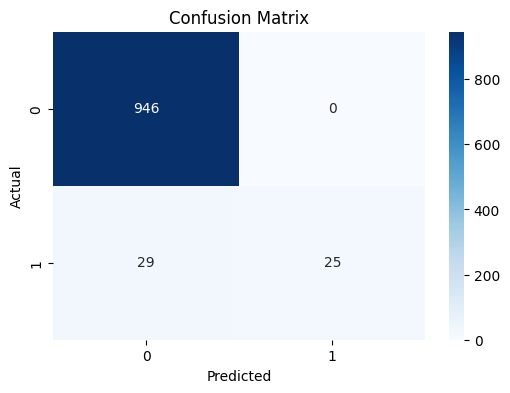

In [18]:
conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
import joblib

joblib.dump(rf_pipeline, "vitals_rf_model.pkl")

['vitals_rf_model.pkl']